In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

print('Libraries imported successfully!')

Libraries imported successfully!


In [4]:
# Load data
df = pd.read_csv('customer_data.csv')

# First look
print('Dataset shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Check column names and data types
print('Column names and types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

Column names and types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Paper

In [6]:
# Fix TotalCharges - convert to number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Basic statistics
print('Basic Statistics:')
print(df.describe())

# Check churn distribution
print('\nChurn Distribution:')
print(df['Churn'].value_counts())
print('\nChurn Percentage:')
print(df['Churn'].value_counts(normalize=True) * 100)

Basic Statistics:
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7032.000000
mean        0.162147    32.371149       64.761692   2283.300441
std         0.368612    24.559481       30.090047   2266.771362
min         0.000000     0.000000       18.250000     18.800000
25%         0.000000     9.000000       35.500000    401.450000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.850000   3794.737500
max         1.000000    72.000000      118.750000   8684.800000

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


C:\Users\Ayesha\AppData\Local\Temp\ipykernel_12060\283930416.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette=['#2ecc71', '#e74c3c'])


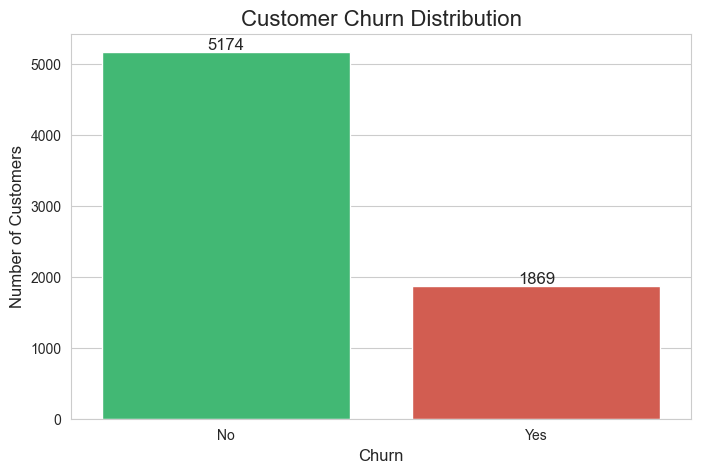

In [7]:
# Visualization 1: Churn Distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Churn', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Customer Churn Distribution', fontsize=16)
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Add numbers on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.show()

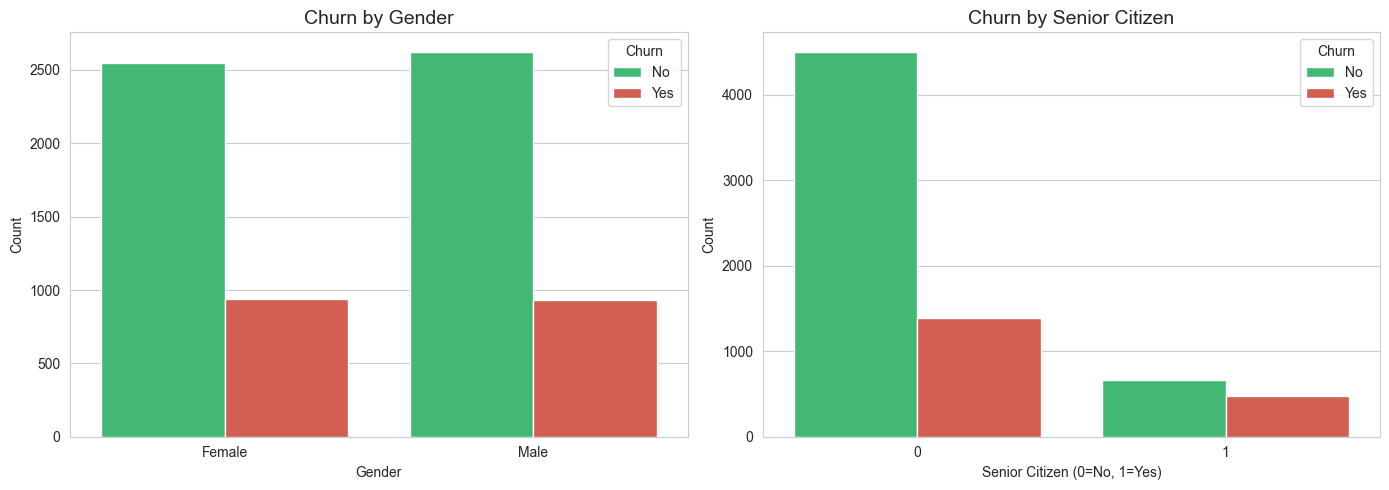

In [8]:
# Visualization 2: Churn by Gender and Senior Citizen
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender
sns.countplot(x='gender', hue='Churn', data=df, 
              palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Churn by Gender', fontsize=14)
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')

# Senior Citizen
sns.countplot(x='SeniorCitizen', hue='Churn', data=df, 
              palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Churn by Senior Citizen', fontsize=14)
axes[1].set_xlabel('Senior Citizen (0=No, 1=Yes)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

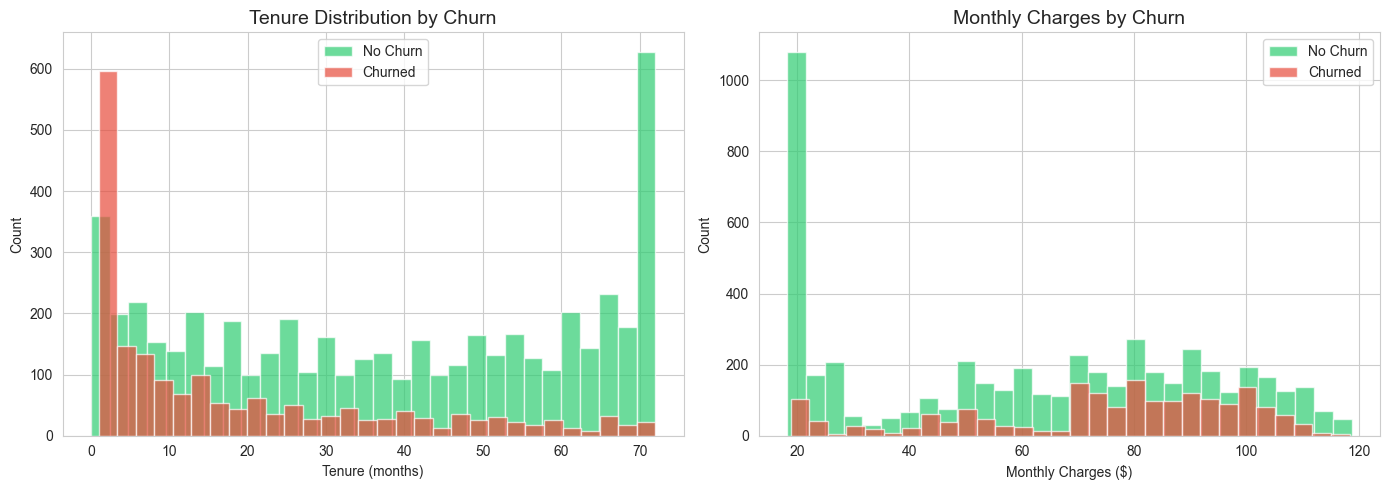

In [9]:
# Visualization 3: Tenure and Monthly Charges
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure distribution
axes[0].hist(df[df['Churn']=='No']['tenure'], bins=30, 
             alpha=0.7, color='#2ecc71', label='No Churn')
axes[0].hist(df[df['Churn']=='Yes']['tenure'], bins=30, 
             alpha=0.7, color='#e74c3c', label='Churned')
axes[0].set_title('Tenure Distribution by Churn', fontsize=14)
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Monthly Charges distribution
axes[1].hist(df[df['Churn']=='No']['MonthlyCharges'], bins=30, 
             alpha=0.7, color='#2ecc71', label='No Churn')
axes[1].hist(df[df['Churn']=='Yes']['MonthlyCharges'], bins=30, 
             alpha=0.7, color='#e74c3c', label='Churned')
axes[1].set_title('Monthly Charges by Churn', fontsize=14)
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

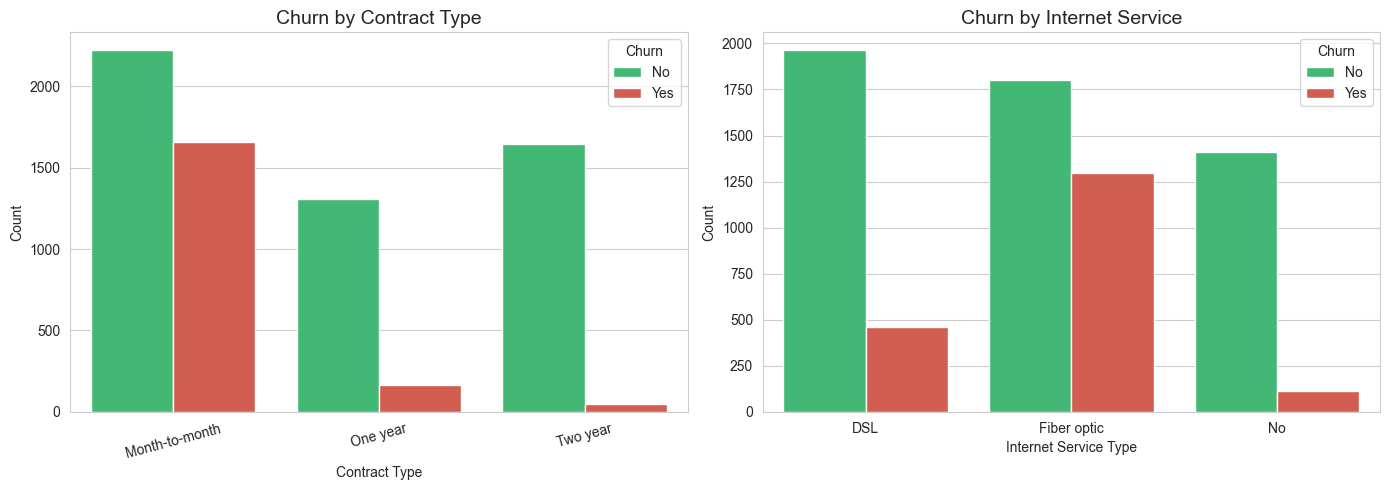

In [10]:
# Visualization 4: Contract and Internet Service
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contract type
sns.countplot(x='Contract', hue='Churn', data=df,
              palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Churn by Contract Type', fontsize=14)
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

# Internet Service
sns.countplot(x='InternetService', hue='Churn', data=df,
              palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Churn by Internet Service', fontsize=14)
axes[1].set_xlabel('Internet Service Type')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

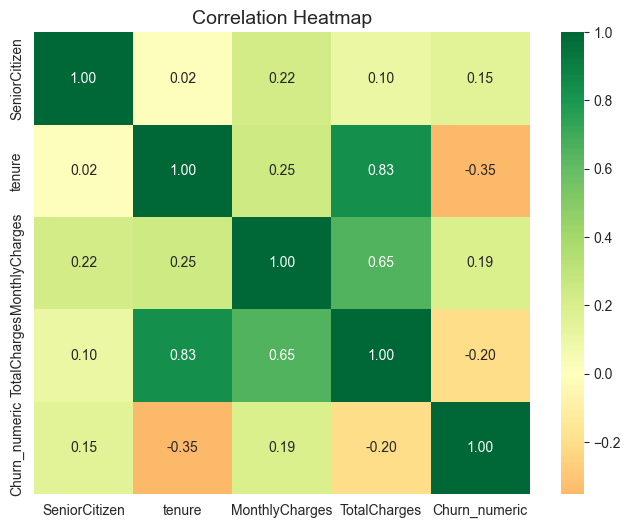

In [11]:
# Visualization 5: Correlation Heatmap
# Convert Churn to numbers for correlation
df['Churn_numeric'] = (df['Churn'] == 'Yes').astype(int)

# Select numeric columns
numeric_cols = df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 
                   'TotalCharges', 'Churn_numeric']]

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            center=0)
plt.title('Correlation Heatmap', fontsize=14)
plt.show()

In [12]:
# Summary of Key Findings
print("=" * 50)
print("KEY INSIGHTS FROM EDA")
print("=" * 50)
print(f"Total Customers: {len(df)}")
print(f"Churn Rate: {df['Churn_numeric'].mean()*100:.1f}%")
print(f"Avg Tenure (Stayed): {df[df['Churn']=='No']['tenure'].mean():.1f} months")
print(f"Avg Tenure (Churned): {df[df['Churn']=='Yes']['tenure'].mean():.1f} months")
print(f"Avg Monthly Charge (Stayed): ${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")
print(f"Avg Monthly Charge (Churned): ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f}")
print("\nTop Churn Risk Factors:")
print("1. Month-to-month contract")
print("2. Fiber optic internet")
print("3. High monthly charges")
print("4. New customers (low tenure)")
print("5. Senior citizens")

KEY INSIGHTS FROM EDA
Total Customers: 7043
Churn Rate: 26.5%
Avg Tenure (Stayed): 37.6 months
Avg Tenure (Churned): 18.0 months
Avg Monthly Charge (Stayed): $61.27
Avg Monthly Charge (Churned): $74.44

Top Churn Risk Factors:
1. Month-to-month contract
2. Fiber optic internet
3. High monthly charges
4. New customers (low tenure)
5. Senior citizens
